# 1. Which segment carries Kalpa's revenue, and which leaf of the tree separates the segments?

**Week 2, Friday. Chapter 1 of 6.** Monday's growth review deck is built today, and this chapter
builds its second page: the revenue tree by segment, from the customer table the team exported on
Thursday.

> **The client asks.** "Monday's growth review deck needs three things I can open on my laptop
> without a login: the revenue tree by segment for both quarters, the top-fifty protect list with a
> lookup so I can find any member by id, and one number on the front page with its trend. Nothing
> that needs Python. If a director changes an assumption in the room, the sheet must recalculate in
> front of them."
>
> Meera's chief of staff, Kalpa Retail

**Who needs the answer.** Meera's chief of staff puts the tree by segment on page two of Monday's
deck, and the directors decide from it which segment the growth plan talks about. A leaf computed the
wrong way puts a tree on the page that does not multiply back to its own revenue, and the first
director who checks the arithmetic stops trusting every page after it.

**The questions on the way.**
1. Which way should a director get the tree: a PivotTable, a formula grid, pasted numbers or a live dashboard?
2. What does one row of the customer table stand for?
3. Which segment carries the revenue?
4. Which leaf separates Retail-Plus from Retail-Core?
5. What does a leaf averaged customer by customer say?
6. Can this table split Q1 from Q2, and does a second calculator agree with the pivot?

**The metric at stake.** Revenue here is booked order value in rupees: every order at the price
charged, whatever became of it, over April to September 2026. The revenue tree splits it into three
leaves that multiply back to it: customers, times orders per customer, times revenue per order.
Kalpa's segments are Retail-Core (everyday shoppers), Retail-Plus (the paid membership tier),
Business (corporate buyers invoiced in large amounts) and Student. The retail dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, carries the tree and the segments
in more depth; nothing here needs it.

Monday's queries on the warehouse, the Postgres database that holds one row per order and that every
sheet ties back to, put Kalpa's revenue at Rs 10,00,00,000
in Q1 (April to June 2026) and Rs 9,84,00,000 in Q2 (July to September 2026). Thursday built one row
per customer in pandas and exported it as a CSV for Marketing. This chapter opens that export the
way a director's Excel does.

**Who else faces it.** Costco, the membership warehouse retailer, reports its sales by member tier.
Its 10-K for the year to 31 August 2025 counts 81.0 million paid members, 38.7 million of them on
the Executive tier, the paid upgrade, and says Executive members made up "approximately 73.6% of
worldwide net sales in 2025" (Costco Form 10-K, fiscal 2025, sec.gov, checked 30 September 2026).
That is the question Kalpa asks of Retail-Plus: how much of the revenue does the paid tier carry, and
through which leaf.

**Setup.** The cell finds the shared helper `kit`, loads the customer table from `../data/` exactly as
Excel opens it, and defines `money()`, which prints rupees in crore, lakh or in full with Indian digit
grouping. Nothing is computed yet.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv
import pandas as pd

DATA = kit.data_dir()
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


def money(n):
    """Rupees the way Kalpa's finance team reads them: crore, lakh, or rupees in full."""
    sign, a = ("-" if n < 0 else ""), abs(n)
    return sign + (crore(a) if a >= 1e7 else lakh(a) if a >= 1e5 else kit.rupees(round(a)))


def change(before, after):
    """The change from before to after, measured on before, in percent."""
    return (after - before) / before * 100

table = pd.read_csv(DATA / "C2_W02_D05_customer_table_STUDENT.csv")

print(len(table), "rows and", len(table.columns), "columns:", ", ".join(table.columns))

300 rows and 6 columns: customer_id, segment, city, orders, revenue, last_order_date


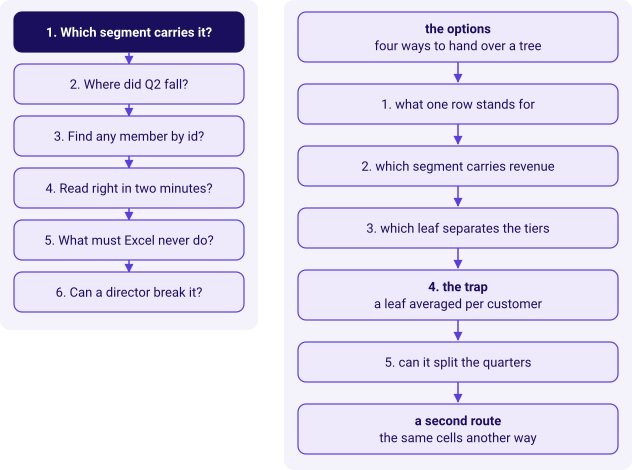

In [2]:
kit.side_by_side(
    kit.ladder(['Which segment carries it?', 'Where did Q2 fall?', 'Find any member by id?', 'Read right in two minutes?', 'What must Excel never do?', 'Can a director break it?'], lit=0, show=False),
    kit.vflow(['the options\nfour ways to hand over a tree', '1. what one row stands for', '2. which segment carries revenue', '3. which leaf separates the tiers', '4. the trap\na leaf averaged per customer', '5. can it split the quarters', 'a second route\nthe same cells another way'], show=False),
)

## Which ways could the team hand a director the tree, and what does each cost on this table?

The chief of staff wants the tree by segment on a laptop with no login, and wants a director to be
able to slice it in the room. Four ways a team could hand it over:

| Option | What the director gets | What it assumes |
|---|---|---|
| a) A PivotTable on the table | A grid a director can re-slice by any column in seconds | The table is right, and someone presses Refresh when it changes |
| b) A SUMIFS and COUNTIFS grid | One formula per cell, each visible and each recalculating at once | The grid holds every slice anyone will ask for |
| c) Values pasted from pandas | The numbers, typed in as values | Nobody asks a new question in the room |
| d) A live dashboard on the warehouse | The warehouse's own numbers | Every director has a login, which the brief rules out |

option,what it takes on this table,what a director can slice,recalculates
a) PivotTable,1 pivot and 8 leaf formulas,"any of the 6 columns, in seconds",on Refresh
b) SUMIFS grid,"12 formulas reading 3,600 cells",only what was built; a city split adds 72,at once
c) pasted values,0 formulas,none,never
d) live dashboard,a query per view,anything,"at once, with a login"


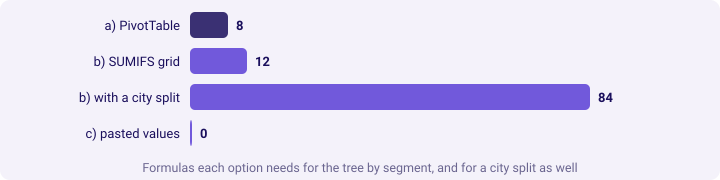

In [3]:
rows, cols = len(table), len(table.columns)
grid = 4 * 3                     # four segments, three measures: customers, orders, revenue
city_split = 6 * 4 * 3           # the same grid again for each of the six cities
sizing = [
    ("a) PivotTable", "1 pivot and 8 leaf formulas", "any of the 6 columns, in seconds", "on Refresh"),
    ("b) SUMIFS grid", f"{grid} formulas reading {grid * rows:,} cells", f"only what was built; a city split adds {city_split}", "at once"),
    ("c) pasted values", "0 formulas", "none", "never"),
    ("d) live dashboard", "a query per view", "anything", "at once, with a login"),
]
kit.table(["option", "what it takes on this table", "what a director can slice", "recalculates"], sizing,
          caption=f"Each option sized on this table: {rows} rows, {cols} columns")
kit.bars([("a) PivotTable", 8), ("b) SUMIFS grid", grid), ("b) with a city split", grid + city_split),
          ("c) pasted values", 0)], lit=(0,),
         title="Formulas each option needs for the tree by segment, and for a city split as well")

**The best-fit call: a, the PivotTable, with each leaf computed beside it from the pivot's sums.** The
first thing a director does in the room is re-slice (by city, by segment), and only the pivot answers
a question nobody built in advance. Its leaves sit beside it as two ratios of its own sums, so they
move when it moves. **The fact that would change it.** A director who changes an assumption rather
than a slice. A PivotTable recalculates only when someone presses Refresh, while a SUMIFS grid
recalculates at once, so the numbers a director's input feeds go in formulas. Chapter 6 builds those.

## 1. What does one row of the customer table stand for?

A Sum in a pivot adds one value per row, so what a row stands for decides what the pivot counts. Say
the grain, what one row stands for, before any pivot.

**Predict before you run.** One row of this table is: a) one order; b) one customer; c) one payment;
d) one customer in one quarter.

In [4]:
ids = table["customer_id"].nunique()
kit.stats([(f"{len(table):,}", "rows", "in the CSV"),
           (f"{ids:,}", "distinct customer ids", "one per row if the grain is a customer"),
           ("6", "columns", "id, segment, city, orders, revenue, last order date")])
kit.table(list(table.columns), table.head(4).values.tolist(), caption="The first four rows, as Excel shows them")
kit.check("one row per customer: rows equal distinct ids", len(table) == ids, f"{len(table)} rows, {ids} ids")

customer_id,segment,city,orders,revenue,last_order_date
C-0001,Retail-Core,Delhi,2,2840,2026-08-06
C-0002,Retail-Core,Chennai,4,6700,2026-07-05
C-0003,Retail-Core,Delhi,6,9710,2026-08-15
C-0004,Retail-Core,Bengaluru,2,3120,2026-08-11


**What happened.** The answer is b. Three hundred rows carry three hundred distinct ids, so one row is
one customer who ordered in the two quarters, with that customer's orders and revenue summed across
April to September. A Sum over this table adds each customer once, which is what the tree needs.

## 2. Which segment carries the revenue?

In Excel: select the table, **Insert, PivotTable**, drag `segment` to Rows, `customer_id` to Values
(Excel counts text, so it shows Count of customer_id), and `orders` and `revenue` to Values (Excel sums
numbers by default). The cell below builds the same grid.

**Predict before you run.** Which segment carries most of the revenue? a) Retail-Core, the most
customers; b) Retail-Plus, the paid tier; c) Business, the corporate buyers; d) no segment carries
more than a third.

Segment,Customers,Orders,Revenue,Share of revenue
Business,39,188,"Rs 19,65,99,040",99.1%
Retail-Core,131,392,"Rs 7,39,320",0.4%
Retail-Plus,106,349,"Rs 9,77,410",0.5%
Student,24,65,"Rs 62,490",0.0%


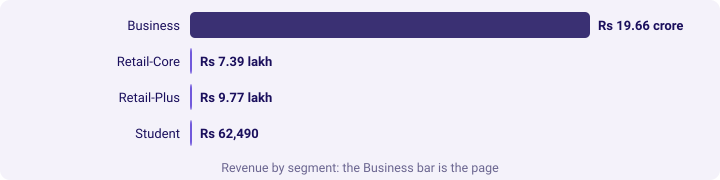

In [5]:
pivot = (table.groupby("segment")
         .agg(customers=("customer_id", "count"), orders=("orders", "sum"), revenue=("revenue", "sum"))
         .reindex(SEGMENTS))
pivot["share"] = pivot["revenue"] / pivot["revenue"].sum() * 100
kit.table(["Segment", "Customers", "Orders", "Revenue", "Share of revenue"],
          [(s, int(r.customers), int(r.orders), kit.rupees(r.revenue), f"{r.share:.1f}%")
           for s, r in pivot.iterrows()],
          caption="The customer table as a pivot by segment, April to September together")
kit.bars([(s, int(r.revenue)) for s, r in pivot.iterrows()], fmt=money, lit=(0,),
         title="Revenue by segment: the Business bar is the page")

In [6]:
kit.check("the four segments count every customer once", int(pivot["customers"].sum()) == len(table),
          f"{int(pivot['customers'].sum())} customers")
kit.check("the four segments add back to the table's own revenue", int(pivot["revenue"].sum()) == int(table["revenue"].sum()))
kit.check("Business carries more than 95 percent of the revenue", pivot.loc["Business", "share"] > 95,
          f"{pivot.loc['Business', 'share']:.1f} percent")

**What happened.** The answer is c. Business, 39 corporate buyers with 188 orders, carries
Rs 19,65,99,040, 99.1 percent of the half-year's revenue. The three consumer segments together carry
under 1 percent, so any number the page shows for the whole company is a Business number, and a
consumer segment can fall by a third without moving it. The front page in chapter 4 has to live with
that.

## 3. Which leaf separates Retail-Plus from Retail-Core?

A member of Retail-Plus spends more than a Retail-Core shopper across the half-year. The tree says
why: more orders each, a bigger basket each time, or both. Each leaf is a ratio of the pivot's own
sums: orders per customer is orders over customers, and revenue per order is revenue over orders. In
Excel they are two formulas beside the pivot, or a calculated field.

**Predict before you run.** Which leaf explains most of the gap in revenue per customer? a) customers;
b) orders per customer; c) revenue per order; d) the two tiers spend the same per customer.

Segment,Customers,Orders per customer,Revenue per order,Revenue per customer
Business,39,4.82,"Rs 10,45,740","Rs 50,41,001"
Retail-Core,131,2.99,"Rs 1,886","Rs 5,644"
Retail-Plus,106,3.29,"Rs 2,801","Rs 9,221"
Student,24,2.71,Rs 961,"Rs 2,604"


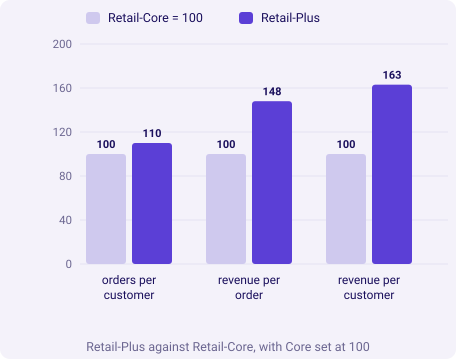

In [7]:
tree = pivot.assign(orders_per_customer=pivot["orders"] / pivot["customers"],
                    revenue_per_order=pivot["revenue"] / pivot["orders"],
                    revenue_per_customer=pivot["revenue"] / pivot["customers"])
kit.table(["Segment", "Customers", "Orders per customer", "Revenue per order", "Revenue per customer"],
          [(s, int(r.customers), f"{r.orders_per_customer:.2f}", kit.rupees(round(r.revenue_per_order)),
            kit.rupees(round(r.revenue_per_customer))) for s, r in tree.iterrows()],
          caption="The leaves per segment, each a ratio of the pivot's sums")
core, plus = tree.loc["Retail-Core"], tree.loc["Retail-Plus"]
kit.columns(["orders per customer", "revenue per order", "revenue per customer"],
            [("Retail-Core = 100", [100, 100, 100]),
             ("Retail-Plus", [round(plus.orders_per_customer / core.orders_per_customer * 100),
                              round(plus.revenue_per_order / core.revenue_per_order * 100),
                              round(plus.revenue_per_customer / core.revenue_per_customer * 100)])],
            title="Retail-Plus against Retail-Core, with Core set at 100")

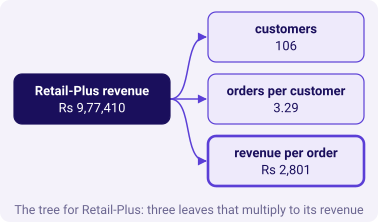

In [8]:
kit.driver_tree({"label": "Retail-Plus revenue", "note": kit.rupees(plus.revenue), "kind": "lit", "children": [
    {"label": "customers", "note": f"{int(plus.customers)}"},
    {"label": "orders per customer", "note": f"{plus.orders_per_customer:.2f}"},
    {"label": "revenue per order", "note": kit.rupees(round(plus.revenue_per_order)), "kind": "known"}]},
    title="The tree for Retail-Plus: three leaves that multiply to its revenue")
for s, r in tree.iterrows():
    rebuilt = r.customers * r.orders_per_customer * r.revenue_per_order
    kit.check(f"{s}: the leaves multiply back to the revenue", abs(rebuilt - r.revenue) < 1)

**What happened.** The answer is c. A Retail-Plus member spends Rs 9,221 across the half-year against
Retail-Core's Rs 5,644, 63 percent more. Orders per customer explain a little of it (3.29 against
2.99, 10 percent more); revenue per order explains most (Rs 2,801 against Rs 1,886, 48.5 percent
more). The paid tier's members fill bigger baskets. Every leaf multiplies back to its segment's
revenue, which is the check each tree on the page has to pass.

## 4. What does a leaf averaged customer by customer say?

**The plausible wrong answer.** A hurried analyst wants revenue per order in the pivot itself. They
add a column to the table, `=revenue/orders`, one value per customer, and drag it into Values. Excel
sums numbers by default, so the first attempt reads as nonsense and is switched to Average, which
looks right.

**Predict before you run.** For Business, the Average of the per-customer column reads: a) exactly
the tree's Rs 10,45,740; b) a little below it; c) about 12 percent above it; d) about twice it.

In [9]:
table["revenue_per_order"] = table["revenue"] / table["orders"]          # the helper column, per customer
by_seg = table.groupby("segment")["revenue_per_order"].agg(["sum", "mean"]).reindex(SEGMENTS)
kit.table(["Segment", "Sum of the column (the default)", "Average of the column", "The tree's leaf"],
          [(s, kit.rupees(round(r["sum"])), kit.rupees(round(r["mean"])), kit.rupees(round(tree.loc[s, "revenue_per_order"])))
           for s, r in by_seg.iterrows()],
          caption="Revenue per order three ways; only the last is revenue divided by orders")
avg_b, true_b = by_seg.loc["Business", "mean"], tree.loc["Business", "revenue_per_order"]
b_orders, b_rev = int(tree.loc["Business", "orders"]), int(tree.loc["Business", "revenue"])
kit.stats([(kit.rupees(round(avg_b)), "Business, averaged per customer", "what the hurried pivot shows"),
           (kit.rupees(round(true_b)), "Business, revenue over orders", "the tree's leaf"),
           (f"{change(true_b, avg_b):+.1f}%", "the averaged leaf's error", "on every Business order")])

Segment,Sum of the column (the default),Average of the column,The tree's leaf
Business,"Rs 4,55,04,669","Rs 11,66,786","Rs 10,45,740"
Retail-Core,"Rs 2,46,750","Rs 1,884","Rs 1,886"
Retail-Plus,"Rs 2,97,862","Rs 2,810","Rs 2,801"
Student,"Rs 23,205",Rs 967,Rs 961


**What happened.** The answer is c: Rs 11,66,786, 11.6 percent above revenue over orders,
Rs 10,45,740.

**Why it is wrong.** The average gives every customer one vote, whatever they bought. Business
customers differ twentyfold in basket size, from Rs 3.34 lakh to Rs 66.98 lakh an order, and a
customer with two huge orders counts as much as a customer with eleven ordinary ones. Revenue per
order is the page's claim about orders, so each order should weigh the same, and only revenue
divided by orders does that. **The check that catches it** is the multiply-back from the question on
which leaf separates the tiers: with the averaged leaf, Business no longer multiplies back to its own
revenue.

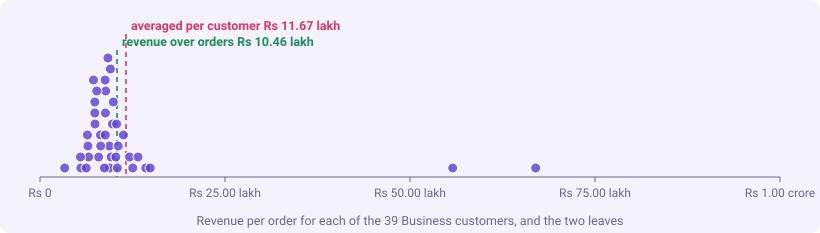

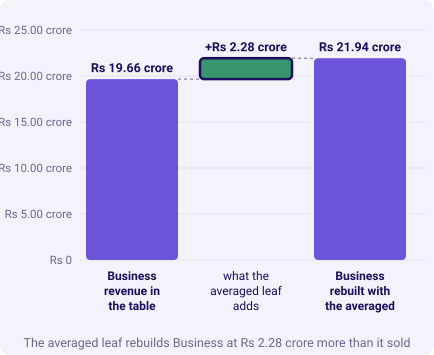

In [10]:
rebuilt_avg = b_orders * avg_b
kit.strip(table.loc[table["segment"] == "Business", "revenue_per_order"].round().tolist(),
          markers=[("averaged per customer", round(avg_b), "bad"), ("revenue over orders", round(true_b), "good")],
          fmt=money, title="Revenue per order for each of the 39 Business customers, and the two leaves")
kit.bridge(("Business revenue in the table", b_rev),
           [("what the averaged leaf adds", round(rebuilt_avg) - b_rev)],
           end_label="Business rebuilt with the averaged leaf", fmt=money, lit=(0,),
           title="The averaged leaf rebuilds Business at Rs 2.28 crore more than it sold")
kit.check("the averaged leaf fails the multiply-back by more than a crore", rebuilt_avg - b_rev > 1e7,
          f"{kit.rupees(round(rebuilt_avg))} against {kit.rupees(b_rev)}")

**The fix.** Revenue per order is the pivot's Sum of revenue divided by its Sum of orders, as a
formula beside the pivot or as a calculated field. Microsoft's page on PivotTable calculations says
"Formulas for calculated fields operate on the sum of the underlying data for any fields in the
formula" (Microsoft Support, Calculate values in a PivotTable, checked 30 September 2026), which is
exactly the ratio of sums. **What changed.** Business revenue per order falls from Rs 11,66,786 to
Rs 10,45,740, and the tree multiplies back to Rs 19,65,99,040 to the rupee. The consumer segments
barely move (Retail-Core Rs 1,884 against Rs 1,886, Retail-Plus Rs 2,810 against Rs 2,801), because
their members' baskets are alike; the averaged leaf is wrong everywhere and badly wrong where
customers differ most in size.

## 5. Can this table split Q1 from Q2?

The chief of staff asked for the tree **for both quarters**. The table's revenue is summed across
April to September, and its only date is `last_order_date`.

**Predict before you run.** How does this table give Q1 against Q2? a) split each customer's revenue
on the quarter of their last order; b) halve each customer's revenue; c) it cannot, since a quarter
split needs one row per order; d) the orders column counts per quarter.

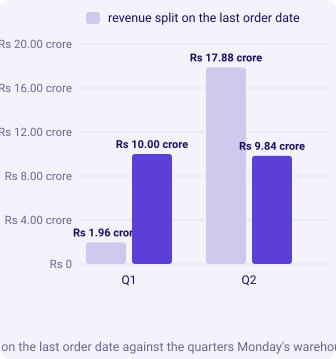

In [11]:
last_q = table["last_order_date"].str[5:7].astype(int).map(lambda m: "Q1" if m <= 6 else "Q2")
split = table.groupby(last_q)["revenue"].sum()
kit.columns(["Q1", "Q2"], [("revenue split on the last order date", [int(split["Q1"]), int(split["Q2"])]),
                          ("the warehouse's quarters (Monday)", [100_000_000, 98_400_000])],
            fmt=money, title="Splitting on the last order date against the quarters Monday's warehouse gave")
kit.check("the table carries no column that says which quarter an order fell in",
          not {"quarter", "order_date"} & set(table.columns))
kit.check("a split on the last order date puts most of the half-year in Q2", split["Q2"] > 5 * split["Q1"],
          f"{money(split['Q2'])} in Q2 against {money(split['Q1'])} in Q1")

**What happened.** The answer is c. `last_order_date` is a recency: it says when a customer last
bought. Split on it, and a customer who bought every month from April and once more in September moves
the whole half-year into Q2, so Q2 reads Rs 17.88 crore against Monday's Rs 9.84 crore. The quarter
split needs one row per order, and only the raw export carries order dates. That is chapter 2.

## A second route: does a plain count of the CSV reach every number the pivot shows?

A second route has to be able to fail when the first is wrong, so it cannot reuse the pivot. This one
reads the CSV as text, line by line, with Python's `csv` module and a running total per segment,
the accumulator from Week 1 Monday. In Excel the same second route is a COUNTIF and two SUMIFS per
segment beside the pivot.

In [12]:
counts = {s: {"customers": 0, "orders": 0, "revenue": 0} for s in SEGMENTS}
with open(DATA / "C2_W02_D05_customer_table_STUDENT.csv", newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        c = counts[row["segment"]]
        c["customers"] += 1
        c["orders"] += int(row["orders"])
        c["revenue"] += int(row["revenue"])
kit.table(["Segment", "Customers", "Orders", "Revenue"],
          [(s, c["customers"], c["orders"], kit.rupees(c["revenue"])) for s, c in counts.items()],
          caption="The same grid, counted from the CSV's text without pandas")
agree = all(counts[s][k] == int(pivot.loc[s, k]) for s in SEGMENTS for k in ("customers", "orders", "revenue"))
kit.check("every cell of the pivot matches the plain count", agree, "12 cells compared")

Segment,Customers,Orders,Revenue
Business,39,188,"Rs 19,65,99,040"
Retail-Core,131,392,"Rs 7,39,320"
Retail-Plus,106,349,"Rs 9,77,410"
Student,24,65,"Rs 62,490"


> **Kavya's review.** "Say what one row is before you pivot, and make every leaf a ratio of the pivot's
> own sums, then multiply the tree back before it goes on a page. A director who multiplies 39 by 4.82
> by Rs 11.67 lakh gets more than Business sold, and after that nobody reads page three."

### In the interview: why does a leaf fail to multiply back, and why hand a director a pivot?

**[D] A leaf of your tree does not multiply back to the revenue. What happened, and what do you fix?**
The leaf was averaged over the rows instead of divided over the totals. An average of per-customer
ratios gives each customer one vote, so a few customers with huge single orders pull it up; here
Business read Rs 11,66,786 an order where revenue over orders is Rs 10,45,740, and the tree came back
Rs 2.28 crore over. I recompute the leaf as the sum of revenue divided by the sum of orders and keep
the multiply-back as the check on every tree I publish.

**[S] SQL, pandas or Excel for a tree a director will slice in the room?** Excel, as a PivotTable on a
table that has already been reconciled upstream, because slicing live is the one thing a director
asks for that neither a query nor a notebook gives them without a login. The numbers themselves come
from the warehouse or pandas; the pivot only presents them.

**[F] Why is a pivot's total only as honest as the table under it?** A pivot adds one value per row,
so the table's grain decides what it counts, and it never checks the table against anything. That is
why the first thing I say before pivoting is what one row stands for, and the last thing I do is tie
the grand total to a number someone upstream owns.

### Depth: why is the average of ratios furthest out where customers differ most in size?

Revenue over orders is an average of each customer's revenue per order, weighted by that customer's
orders: a customer with eleven orders counts eleven times. The plain Average weights every customer
once. The two agree only when every customer has the same number of orders, or when how often a
customer orders has nothing to do with how big the basket is. Retail-Core members order anywhere from
once to fourteen times, at baskets between Rs 820 and Rs 3,000, and the number of orders tells you
nothing about the basket (a correlation of 0.01), so the two leaves differ by Rs 2. Business accounts
order between once and eleven times at baskets twentyfold apart, and the accounts with fewer orders
lean towards larger baskets (a correlation of -0.18; the two largest belong to accounts with two and
four orders), so the unweighted average runs 11.6 percent high.

**A spreadsheet that divided by the wrong total.** In January 2013 JPMorgan Chase's own task force
reported on the 2012 losses in its Chief Investment Office. In the spreadsheet behind a new risk
model, "after subtracting the old rate from the new rate, the spreadsheet divided by their sum
instead of their average, as the modeler had intended", which "likely had the effect of muting
volatility by a factor of two and of lowering the VaR" (Report of JPMorgan Chase & Co. Management
Task Force Regarding 2012 CIO Losses, 16 January 2013, page 128, read from the Yale Program on
Financial Stability archive, checked 30 September 2026). The bank divided by the wrong total, and the
averaged leaf weights its customers wrongly; both are ratios that nobody checked against their parts,
the bank's at a far larger scale.

## Which segment carries the revenue, and which leaf separates the tiers, question by question?

1. The PivotTable, with each leaf computed beside it from its sums, because a director re-slices in the room; formulas take over where a director's input must recalculate at once.
2. One row of the customer table is one customer who ordered in the two quarters: 300 rows, 300 ids.
3. Business carries 99.1 percent of the half-year's revenue: 39 customers, Rs 19,65,99,040.
4. Revenue per order separates the tiers: Retail-Plus Rs 2,801 against Retail-Core's Rs 1,886, where orders per customer differ by 10 percent.
5. A leaf averaged per customer reads Business at Rs 11,66,786 an order, 11.6 percent high, and the tree multiplies back Rs 2.28 crore over; revenue over orders fixes it.
6. The table cannot split the quarters, since a split on the last order date puts Rs 17.88 crore in Q2; a plain count of the CSV matches all 12 cells of the pivot.

The next question is chapter 2's: the chief of staff wants both quarters, so the tree has to come from
the export that carries order dates.

In [13]:
kit.check_summary()